In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("smartcart_customers.csv")
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [4]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

In [5]:
df = df.dropna(axis=0)
df.shape

(2216, 22)

## Feature Engineering

In [6]:
## Adding new column - Age, instated of "Year Birth"

df["Age"] = 2026 - df["Year_Birth"]

In [7]:
## adding new Column - Customer_Tenure_Days, instated of "Dt_customer"

df['Dt_Customer'] = pd.to_datetime(df["Dt_Customer"], dayfirst=True)

Reference_date = df["Dt_Customer"].max()

df["Customer_Tenure_Days"] = (Reference_date - df["Dt_Customer"]).dt.days

In [8]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Tenure_Days'],
      dtype='object')

In [9]:
# Adding new column - Total_Spending (Combining all user expenses)

df["Total_Spending"] = df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"] + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"]


In [10]:
# Adding new column - Total_Children (Combining Combining Kidhome + Teenhome)

df["Total_Children"] = df["Kidhome"] + df["Teenhome"] 

In [11]:
df["Education"].value_counts()

Education
Graduation    1116
PhD            481
Master         365
2n Cycle       200
Basic           54
Name: count, dtype: int64

In [12]:
# in Education, Storing the data in three categories- Undergraduate, Graduate, Postgraduate


df["Education"] = df["Education"].replace({
    "Basic": "Undergraduate", "2n Cycle": "Undergraduate",
    "Graduate": "Graduate",
    "Master": "Postgraduate",
    "Master": "Postgraduate", "PhD": "Postgraduate" 
})

In [13]:
df["Education"].value_counts()

Education
Graduation       1116
Postgraduate      846
Undergraduate     254
Name: count, dtype: int64

In [14]:
df["Marital_Status"].value_counts()

Marital_Status
Married     857
Together    573
Single      471
Divorced    232
Widow        76
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [15]:
# In Marital Status, Storing the data in two categories- Partner, Alone

df["Living_With"] = df["Marital_Status"].replace({
    "Married": "Partner", "Together": "Partner",
    "Single": "Alone", "Divorced": "Alone",
    "Widow": "Alone", "Absurd": "Alone", "YOLO": "Alone"
})


In [16]:
df["Marital_Status"].value_counts()

Marital_Status
Married     857
Together    573
Single      471
Divorced    232
Widow        76
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

## Dropping Unnecessary Columns

In [17]:
df.head()



,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_With
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,10,4,7,0,1,69,663,1617,0,Alone
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,1,2,5,0,0,72,113,27,2,Alone
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,2,10,4,0,0,61,312,776,0,Partner
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0,4,6,0,0,42,139,53,1,Partner
4,5324,1981,Postgraduate,Married,58293.0,1,0,2014-01-19,94,173,...,3,6,5,0,0,45,161,422,1,Partner


In [18]:
col = ["ID", "Year_Birth", "Marital_Status", "Kidhome", "Teenhome", "Dt_Customer", ]

spending_Cols = ["MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds"]

col_to_drop = col + spending_Cols

df_cleaned = df.drop(columns=col_to_drop)

In [19]:
print(df.shape)
print(df_cleaned.shape)

(2216, 27)
(2216, 15)


In [20]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_With
0,Graduation,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduation,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduation,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduation,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


## Outliers

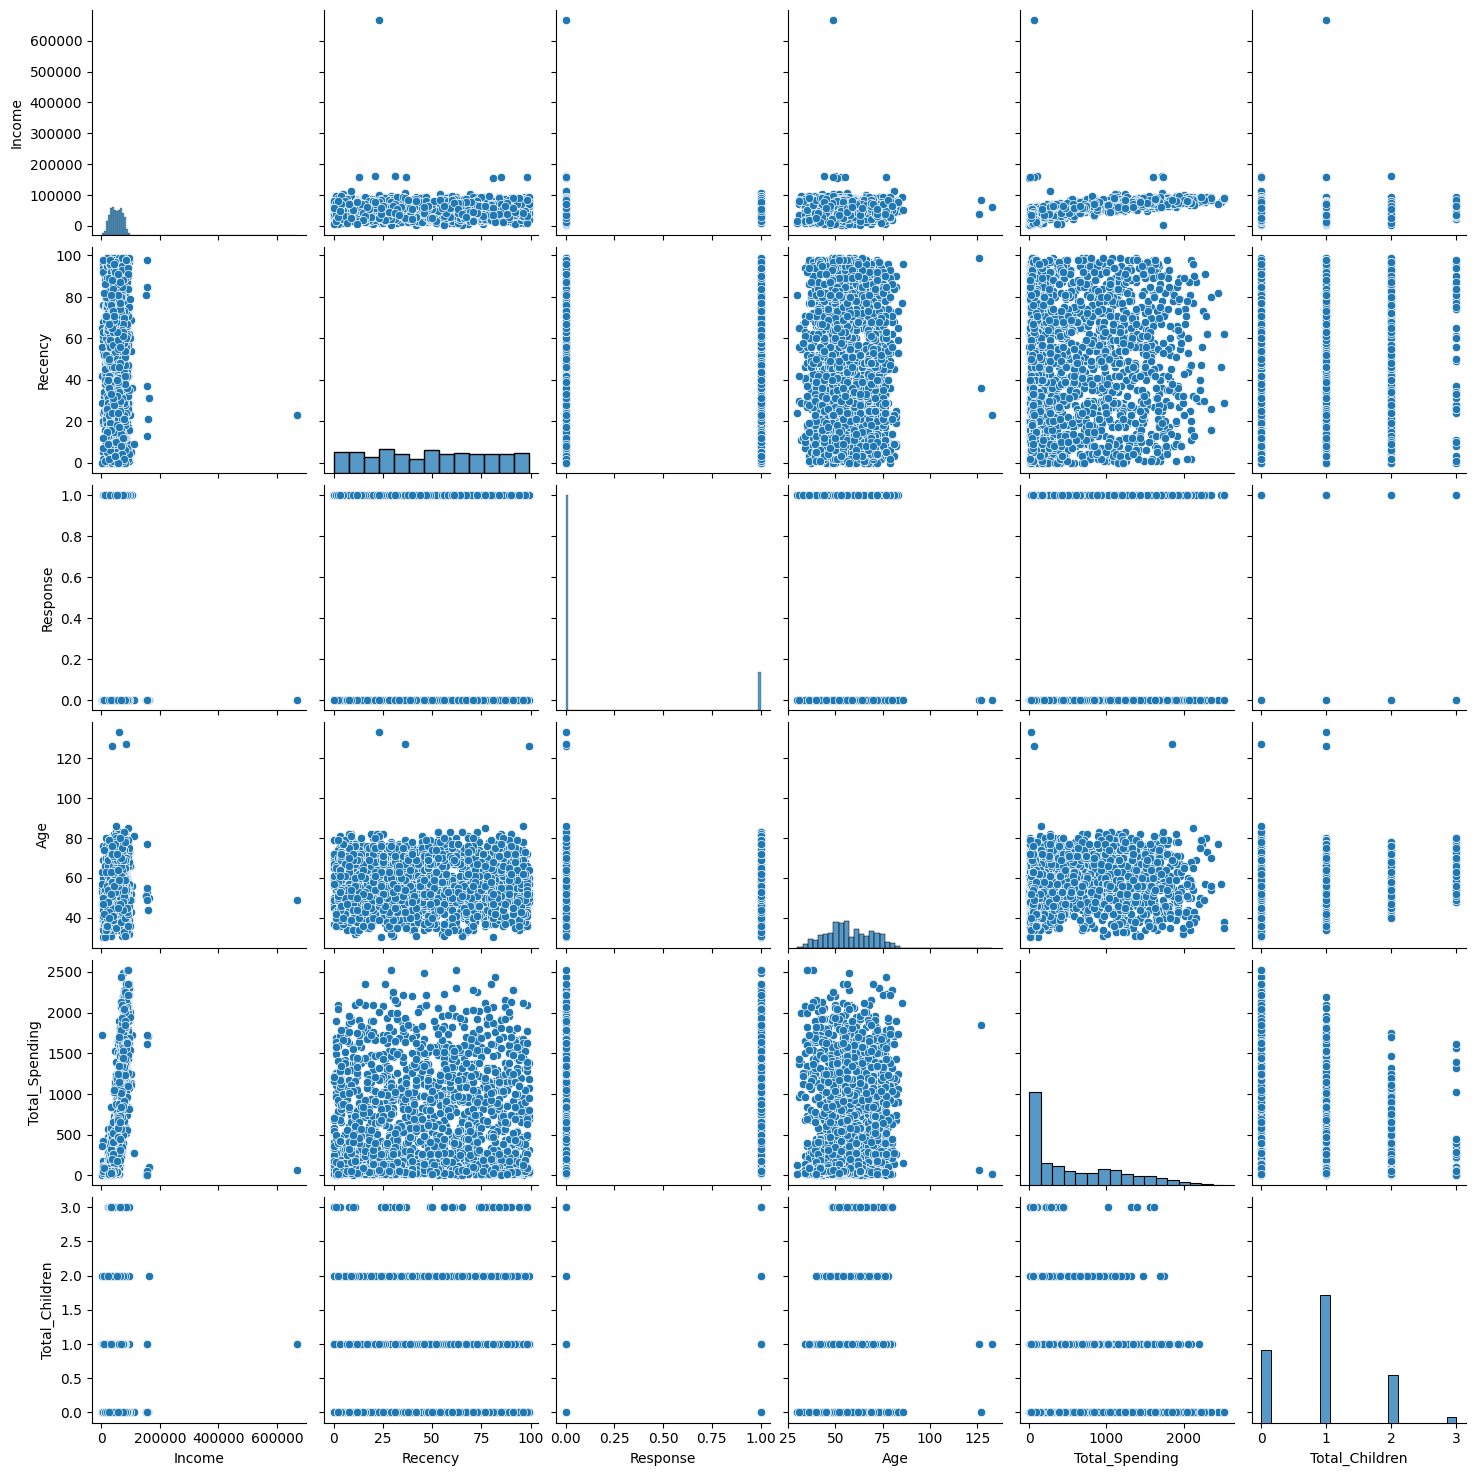

In [21]:
cols = ["Income", "Recency", "Response", "Age", "Total_Spending", "Total_Children"]

## Relative Plots of some feature - pair plots
sns.pairplot(df_cleaned[cols])

In [22]:
## Remove Outliers - Removing Age(more than 90) and Income(more than 60k)

print(f"Data size with Outliers: {len(df_cleaned)}")

df_cleaned = df_cleaned[(df_cleaned["Age"] < 90)]
df_cleaned = df_cleaned[(df_cleaned["Income"] < 600_000)]

print(f"Data size without Outliers: {len(df_cleaned)}")

Data size with Outliers: 2216
Data size without Outliers: 2212


## Heatmap

<Axes: >

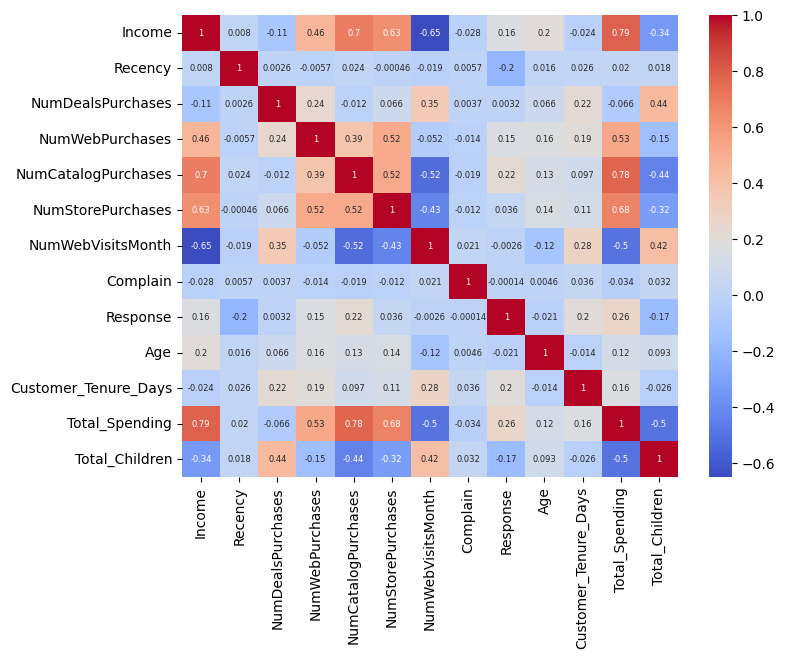

In [23]:
## Understanding the features with other features

corr = df_cleaned.corr(numeric_only=True)

plt.figure(figsize=(8,6))

sns.heatmap(
    corr, 
    annot=True,
    annot_kws= {"size":6},
    cmap="coolwarm"
)

## Feature Encoding
Converting the categorical data into numerical data

In [24]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder()

cat_cols = ["Education", "Living_With"]

enc_cols = ohe.fit_transform(df_cleaned[cat_cols])

In [25]:
enc_df = pd.DataFrame(enc_cols.toarray(), columns=ohe.get_feature_names_out(cat_cols), index=df_cleaned.index)

In [26]:
df_encoded = pd.concat([df_cleaned.drop(columns=cat_cols), enc_df], axis=1)

In [27]:
df_encoded.shape

(2212, 18)

In [28]:
df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Education_Graduation,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0


In [29]:
X = df_encoded

## Scaling

In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

## Visualize

In [31]:
X_scaled.shape

(2212, 18)

Variance ratio of 2D = [0.23258254 0.11390916]


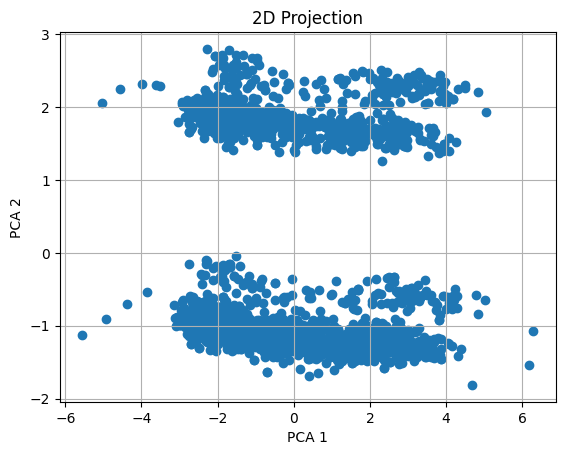

In [32]:
'''2D'''

# PCA is needed for dimensionality reduction
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

'''Plot'''
plt.scatter(x=X_pca[:,0], y=X_pca[:,1])
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("2D Projection")
plt.grid()

print(f"Variance ratio of 2D = {pca.explained_variance_ratio_}")

Variance ratio of 3D = [0.23258254 0.11390916 0.10418299]


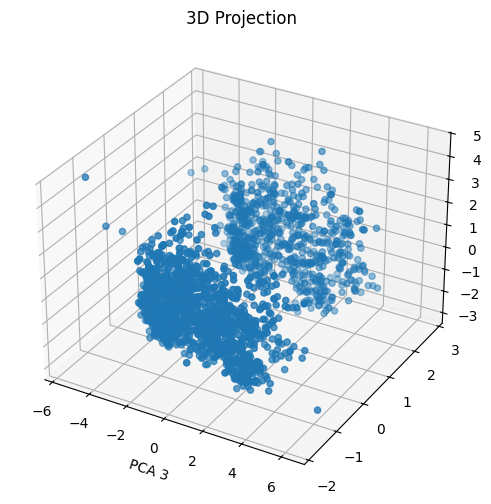

In [33]:
'''3D'''

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

'''Plot'''
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_pca[:, 0], X_pca[:,1], X_pca[:,2])
ax.set_xlabel("PCA 1")
ax.set_xlabel("PCA 2")
ax.set_xlabel("PCA 3")
ax.set_title("3D Projection")
plt.grid()

print(f"Variance ratio of 3D = {pca.explained_variance_ratio_}")

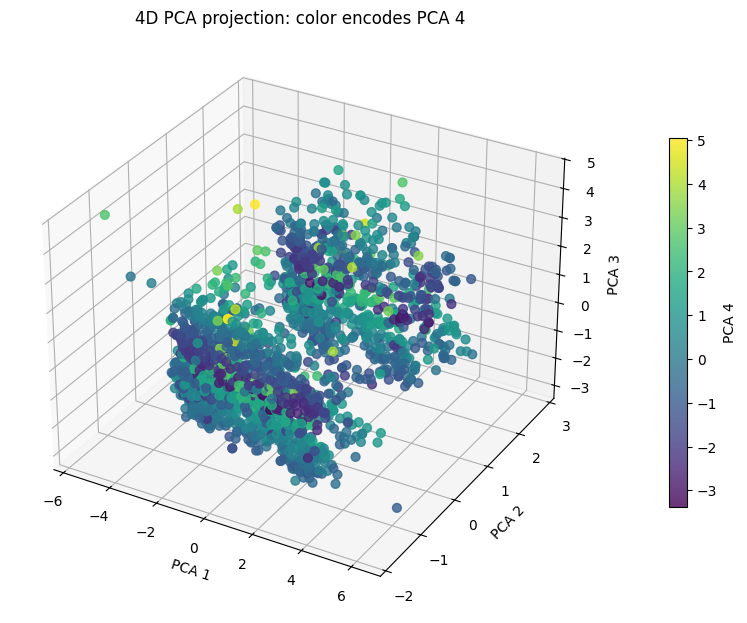

Variance ratio of 4D = [0.23258254 0.11390916 0.10418299 0.09926935]


In [34]:
'''4D'''

pca = PCA(n_components=4)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=[f"PCA {i}" for i in range(1, 5)])

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(
    pca_df['PCA 1'],
    pca_df['PCA 2'],
    pca_df['PCA 3'],
    c=pca_df['PCA 4'],
    cmap='viridis',
    s=40,
    alpha=0.8
)
ax.set_xlabel('PCA 1')
ax.set_ylabel('PCA 2')
ax.set_zlabel('PCA 3')
ax.set_title('4D PCA projection: color encodes PCA 4')
cbar = plt.colorbar(scatter, ax=ax, shrink=0.6, pad=0.1)
cbar.set_label('PCA 4')
plt.show()

print(f"Variance ratio of 4D = {pca.explained_variance_ratio_}")

## Analyze K value
#### 1. Elbow Method

In [35]:
from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

In [36]:
knee = KneeLocator(range(1, 11), wcss, curve="convex", direction="decreasing")
optimal_k = knee.elbow

print(f"Best K = {optimal_k}")

Best K = 3


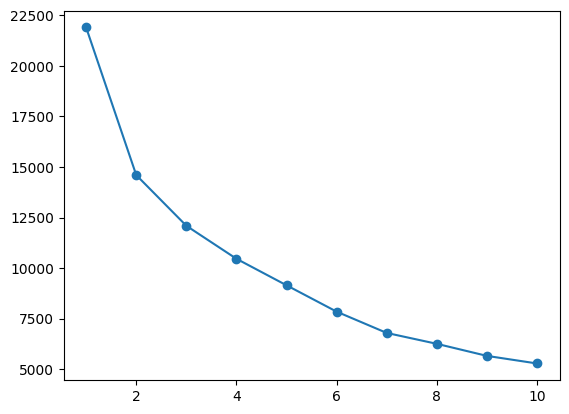

In [37]:
# Plot

plt.plot(range(1,11), wcss, marker="o")

#### 2. Silhouette Score

Text(0, 0.5, 'Silhouette SCore')

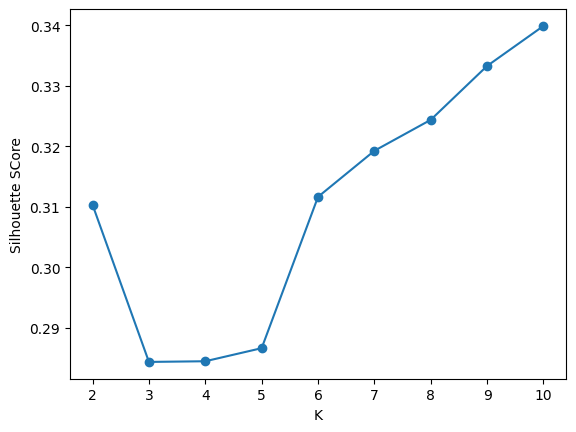

In [38]:
# Silhouette SCore

from sklearn.metrics import silhouette_score

scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    scores.append(score)
    
    
## Plot

plt.plot(range(2, 11), scores, marker="o")
plt.xlabel("K")
plt.ylabel("Silhouette SCore")

Text(0, 0.5, 'Silhouette Score')

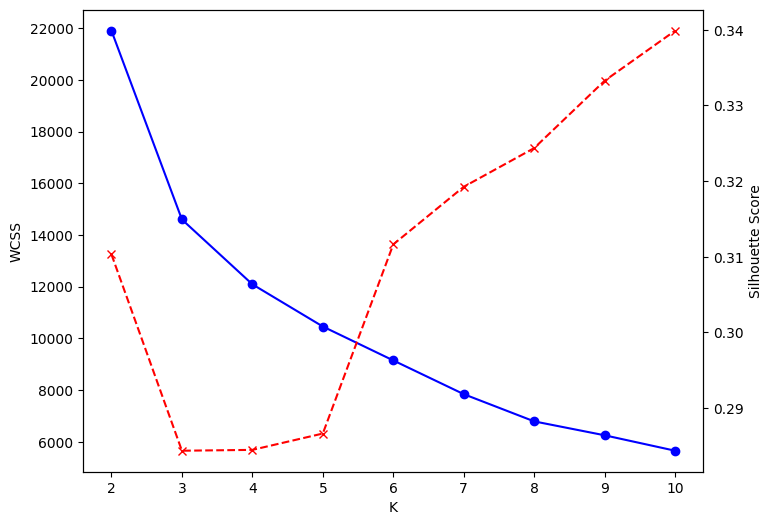

In [39]:
## Combined Plot

k_range = range(2, 11)

fig, ax1 = plt.subplots(figsize=(8,6))

ax1.plot(k_range, wcss[:len(k_range)], marker="o", color="blue")
ax1.set_xlabel("K")
ax1.set_ylabel("WCSS")

ax2 = ax1.twinx()
ax2.plot(k_range, scores[:len(k_range)], marker="x", color="red", linestyle="--")
ax2.set_ylabel("Silhouette Score")

## Clustering 
#### 1. K_means

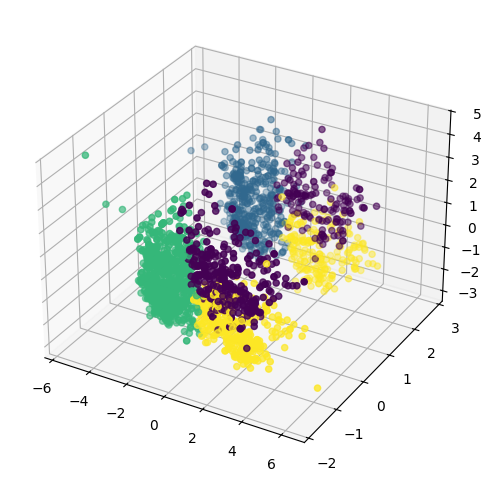

In [40]:
# K_means

kmeans = KMeans(n_clusters=4, random_state=42)

labels_kmeans = kmeans.fit_predict(X_pca)

# plot

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_pca[:, 0], X_pca[:,1], X_pca[:,2], c=labels_kmeans)

#### 2. Agglomerative Clustering

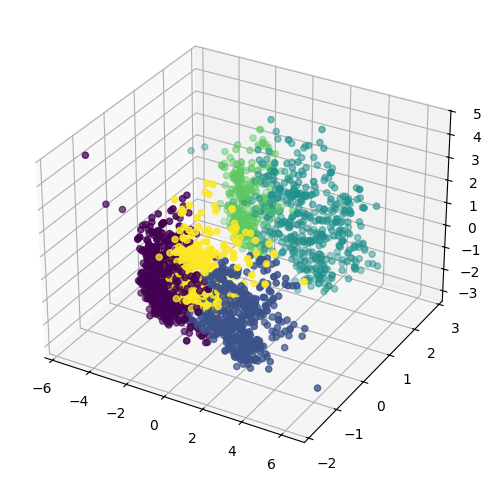

In [41]:
## Agglomerative Clustering

from sklearn.cluster import AgglomerativeClustering

agg_clf = AgglomerativeClustering(n_clusters=5, linkage="ward")
labels_agg = agg_clf.fit_predict(X_pca)


# Plot

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_pca[:, 0], X_pca[:,1], X_pca[:,2], c=labels_agg)

# Characterization of Clusters

In [42]:
X["cluster"] = labels_agg

In [43]:
X.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Education_Graduation,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner,cluster
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0,2
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0,3
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0,4


C:\Users\Chirag Singh\AppData\Local\Temp\ipykernel_7144\3322367495.py:3: UserWarning: 
The palette list has fewer values (4) than needed (5) and will cycle, which may produce an uninterpretable plot.
  sns.countplot(x=X["cluster"], palette=pal, hue=X["cluster"])


<Axes: xlabel='cluster', ylabel='count'>

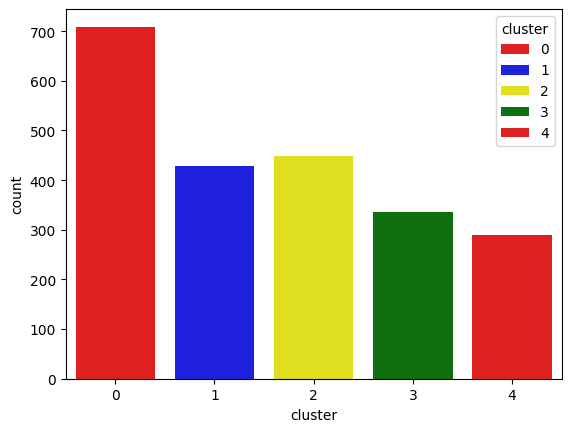

In [44]:
pal = ["red", "blue", "yellow", "green"]

sns.countplot(x=X["cluster"], palette=pal, hue=X["cluster"])

C:\Users\Chirag Singh\AppData\Local\Temp\ipykernel_7144\3499934373.py:3: UserWarning: 
The palette list has fewer values (4) than needed (5) and will cycle, which may produce an uninterpretable plot.
  sns.scatterplot(x=X["Total_Spending"], y=X["Income"], hue=X["cluster"], palette=pal)


<Axes: xlabel='Total_Spending', ylabel='Income'>

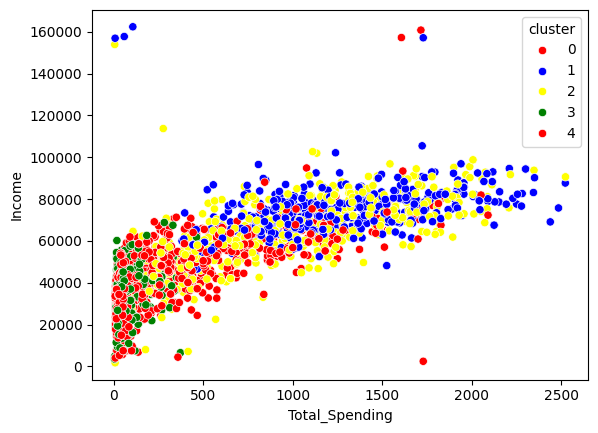

In [45]:
## Income & Spending Patterns

sns.scatterplot(x=X["Total_Spending"], y=X["Income"], hue=X["cluster"], palette=pal)

In [46]:
## Cluster Summary

cluster_summary = X.groupby("cluster").mean()
print(cluster_summary)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
cluster                                                                
0        35886.005642  49.506347           2.091678         2.306065   
1        74631.508159  48.349650           1.375291         5.261072   
2        65672.576837  49.371938           2.454343         5.616927   
3        33904.782090  48.585075           1.997015         2.017910   
4        57336.913793  48.775862           4.475862         6.734483   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
cluster                                                                        
0                   0.650212           3.480959           6.345557  0.009873   
1                   5.557110           8.543124           2.972028  0.006993   
2                   4.336303           7.810690           4.487751  0.006682   
3                   0.543284           3.083582           6.414925  0.011940   
4              